# Домашнее задание: KNN классификация

## 1. Загрузка и подготовка данных

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

%matplotlib inline

In [11]:
all_data = pd.read_csv('forest_dataset.csv')

labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42, stratify=labels
)

## 2. Базовый KNN классификатор

In [12]:
clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)

base_acc = accuracy_score(test_labels, y_pred)
print(f'Базовый KNN (n_neighbors=5, euclidean, uniform): {base_acc:.4f}')

Базовый KNN (n_neighbors=5, euclidean, uniform): 0.7500


## 3. Подбор гиперпараметров

In [13]:
params = {
    'n_neighbors': np.arange(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance'],
}

clf_grid = GridSearchCV(KNeighborsClassifier(), params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['manhattan', 'euclidean'], 'n_neighbors': array([ 1, 2..., 8, 9, 10]), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [14]:
print(f'Лучшие параметры: {clf_grid.best_params_}')

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': np.int64(4), 'weights': 'distance'}


## 4. Оптимальная модель KNN

In [15]:
optimal_clf = KNeighborsClassifier(**clf_grid.best_params_)
optimal_clf.fit(train_feature_matrix, train_labels)
y_pred_opt = optimal_clf.predict(test_feature_matrix)
pred_prob = optimal_clf.predict_proba(test_feature_matrix)

opt_acc = accuracy_score(test_labels, y_pred_opt)
print(f'Точность оптимальной модели KNN: {opt_acc:.4f}')

Точность оптимальной модели KNN: 0.7825


## 5. Визуализация распределения классов

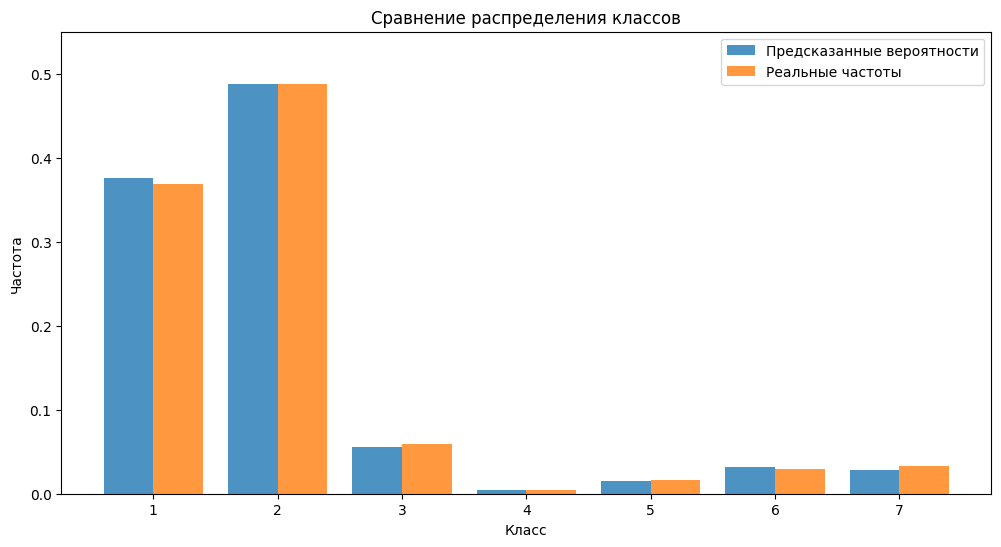

In [16]:
unique, freq = np.unique(test_labels, return_counts=True)
freq = freq / len(test_labels)
pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(12, 6))
x_pos = np.arange(1, len(unique) + 1)

plt.bar(x_pos - 0.2, pred_freq, width=0.4, label='Предсказанные вероятности', alpha=0.8)
plt.bar(x_pos + 0.2, freq, width=0.4, label='Реальные частоты', alpha=0.8)

plt.xlabel('Класс')
plt.ylabel('Частота')
plt.title('Сравнение распределения классов')
plt.legend()
plt.xticks(x_pos)
plt.ylim(0, 0.55)
plt.show()

## 6. Сравнение с логистической регрессией

In [8]:
clf_log = OneVsRestClassifier(LogisticRegression(C=1, solver='liblinear'))
clf_log.fit(train_feature_matrix, train_labels)
log_acc = accuracy_score(test_labels, clf_log.predict(test_feature_matrix))

print(f'Логистическая регрессия (OneVsRest + liblinear): {log_acc:.4f}')
print(f'KNN оптимальный: {opt_acc:.4f}')
print(f'Разница: {opt_acc - log_acc:.4f}')

Логистическая регрессия (OneVsRest + liblinear): 0.7025
KNN оптимальный: 0.7825
Разница: 0.0800


## 7. Анализ моделей

**KNN:**
- Преимущества: нелинейные границы, отсутствие предположений о распределении данных
- Недостатки: вычислительная сложность, чувствительность к масштабу признаков
- Лучше работает при сложных нелинейных зависимостях

**Логистическая регрессия:**
- Преимущества: интерпретируемость, быстрая работа, устойчивость к выбросам
- Недостатки: линейная граница решений, хуже работает с нелинейными данными
- Предпочтительнее для задач с линейно разделимыми классами

В данном случае точность KNN оказалась выше, что говорит о нелинейной структуре данных.

## 8. ROC-кривые и AUC

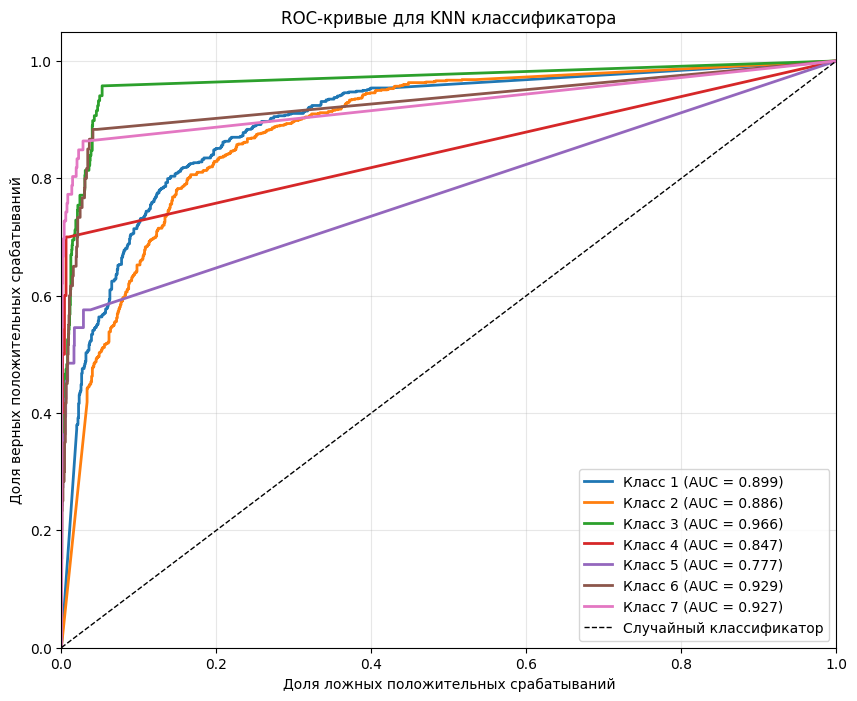


Значения AUC для каждого класса:
  Класс 1: 0.8987
  Класс 2: 0.8859
  Класс 3: 0.9657
  Класс 4: 0.8473
  Класс 5: 0.7769
  Класс 6: 0.9295
  Класс 7: 0.9268

Среднее AUC (macro): 0.8901


In [9]:
test_labels_bin = label_binarize(test_labels, classes=np.unique(labels))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))

for i in range(len(np.unique(labels))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Класс {i+1} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложных положительных срабатываний')
plt.ylabel('Доля верных положительных срабатываний')
plt.title('ROC-кривые для KNN классификатора')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print('\nЗначения AUC для каждого класса:')
for i in range(len(np.unique(labels))):
    print(f'  Класс {i+1}: {roc_auc[i]:.4f}')

print(f'\nСреднее AUC (macro): {np.mean(list(roc_auc.values())):.4f}')